# Generative Adversarial Networks

[Generative Adversarial Nets](https://arxiv.org/pdf/1406.2661)

Two models:
* **Generator**: aims to generate new data similar to the expected one.
* **Discriminator**: aims to recognize if an input data is 'real' — belongs to the original dataset – or if it is 'fake' (generated).

* **Generator Network**: Generates realistic images, after training, from random samples in latent space.

* **Discriminator Network**: Classifies whether an image is real (1) or fake (0).

* **Training GANs (competition)**: The Generator learns how to create ralistic data to the Discriminator, which tries to distinguish between real and fake.
    
### Network Design

<figure>
<img src="https://raw.githubusercontent.com/Rio-HEPLab/ML4Physics/PPGF-2025-1/pics/GAN-Digits.jpg" width=600>
<figcaption>Fig.1: GAN architecture. Credits: https://developer.ibm.com/articles/generative-adversarial-networks-explained/</figcaption>
</figure>

### Cost function

Minimax cost function:

$$ \underset{\theta_{g}}{min} \: \underset{\theta_{d}}{max} \; V(D,G) = \mathbb{E}_{x\sim p_{data}(x)}[log D_{\theta_{d}}(x)] + \mathbb{E}_{z\sim p_{z}(z)}[log(1 - D_{\theta_{d}}(G_{\theta_{g}}(z)))]$$

* $D_{\theta_{d}}$ wants to maximize  objective such that $D(x)$ is close to 1 (real) and $D(G(z))$ is close to 0 (fake).
* $G_{\theta_{g}}$ wants to minimize objective such that $D(G(z))$ is close to 1 (discriminator is fooled into thinking generated G(z) is real).

Alternate between:
1. Gradient ascent on D
$$\underset{\theta_{d}}{max} [\mathbb{E}_{x\sim p_{data}(x)}log D_{\theta_{d}}(x) + \mathbb{E}_{z\sim p_{z}(z)}log(1 - D_{\theta_{d}}(G_{\theta_{g}}(z)))]$$

2. Gradient ascent on generator, different objective
$$\underset{\theta_{g}}{max}[\mathbb{E}_{z\sim p_{z}(z)}[log( D_{\theta_{d}}(G_{\theta_{g}}(z)))] $$

(Maximize likelihood of discriminator being wrong instead of minimizing likelihood of discriminator being correct, same objetive of fooling discriminator)

* The Discriminator is trained to correctly classify the input data as either real or fake.
    * It's weights are updated as to maximize the probability that any real data input x is classified as belonging to the real dataset, while minimizing the probability that any fake image is classified as belonging to the real dataset.
    * The loss/error function used maximizes the function D(x), and it also minimizes D(G(z)).
* The Generator is trained to fool the Discriminator by generating data as realistic as possible. It's weighta are optimized to maximize the probability that any fake image is classified as belonging to the real dataset. This means that the loss/error function used for this network maximizes D(G(z)).

### Load data

In [1]:
import numpy as np
import matplotlib.pyplot as plt


#### MNIST data

In [2]:
import tensorflow as tf
tf.config.run_functions_eagerly(True) # This ensures eager execution within tf.function

# from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization
from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.optimizers.legacy import Adam
# from keras.optimizers import SGD
from tensorflow.keras import initializers

2025-06-23 20:08:36.755890: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750709316.779663     421 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750709316.792040     421 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
num_samples = 40000
X_train = X_train[ : num_samples ]
y_train = y_train[ : num_samples ]
print ( X_train.shape )

(40000, 28, 28)


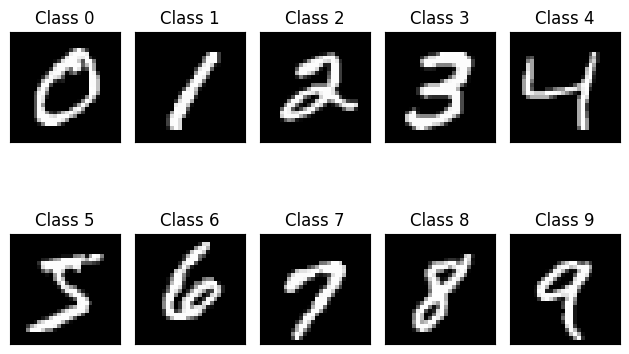

In [4]:
fig = plt.figure()
for i in range(10):
    plt.subplot(2, 5, i+1)
    x_y = X_train[y_train == i]
    plt.imshow(x_y[0], cmap='gray', interpolation='none')
    plt.title("Class %d" % (i))
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()

#### Reshaping and normalizing the inputs

In [5]:
print('X_train.shape', X_train.shape)

# Reshape and normalize
X_train = X_train.reshape( X_train.shape[0], 28*28 )
X_train = ( X_train.astype('float32') / 255 - 0.5 ) * 2
print('X_train reshape:', X_train.shape)

# Batch and shuffle the data
batch_size = 256
train_dataset = tf.data.Dataset.from_tensor_slices( X_train ).shuffle(num_samples).batch( batch_size )

X_train.shape (40000, 28, 28)
X_train reshape: (40000, 784)


I0000 00:00:1750709321.261615     421 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


### Model

#### Generator

In [6]:
# latent space dimension
latent_dim = 100

# image dimension 28x28
img_dim = 784

kernel_init = initializers.RandomNormal(stddev=0.02)

# Generator network
generator = Sequential()

# Input layer and hidden layer 1
generator.add( Dense( 128, input_shape=(latent_dim,), kernel_initializer=kernel_init ) )
generator.add( LeakyReLU(alpha=0.2) )
generator.add( BatchNormalization(momentum=0.8) )

# Hidden layer 2
generator.add( Dense(256) )
generator.add( LeakyReLU(alpha=0.2) )
generator.add( BatchNormalization(momentum=0.8) )

# Hidden layer 3
generator.add( Dense(512) )
generator.add( LeakyReLU(alpha=0.2) )
generator.add( BatchNormalization(momentum=0.8) )

# Output layer
generator.add( Dense(img_dim, activation='tanh') )


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [7]:
# Summary of generator
generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 784)                 │         402,192 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 583,312 (2.23 MB)

 Trainable params: 581,520 (2.22 MB)

 Non-trainable params: 1,792 (7.00 KB)

#### Discriminator

In [8]:
# Discriminator network
discriminator = Sequential()

# Input layer and hidden layer 1
discriminator.add (Dense(128, input_shape=(img_dim,), kernel_initializer=kernel_init) )
discriminator.add (LeakyReLU(alpha=0.2) )

# Hidden layer 2
discriminator.add( Dense(256) )
discriminator.add( LeakyReLU(alpha=0.2) )

# Hidden layer 3
discriminator.add( Dense(512) )
discriminator.add( LeakyReLU(alpha=0.2) )

# Output layer
discriminator.add( Dense(1, activation='sigmoid') )


In [9]:
# Summary of discriminator
discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_4 (LeakyReLU)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 512)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_5 (LeakyReLU)            │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 265,601 (1.01 MB)

 Trainable params: 265,601 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

### Train

Epoch: 0, disc. loss: 0.025126906111836433, gen. loss: 3.6160778999328613. Time for epoch 1 is 27.497873067855835 sec
Epoch: 1, disc. loss: 0.07358519732952118, gen. loss: 3.1811728477478027. Time for epoch 2 is 25.835682153701782 sec
Epoch: 2, disc. loss: 0.17891234159469604, gen. loss: 2.173210382461548. Time for epoch 3 is 25.70231819152832 sec
Epoch: 3, disc. loss: 0.24962329864501953, gen. loss: 1.849260687828064. Time for epoch 4 is 25.642765522003174 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


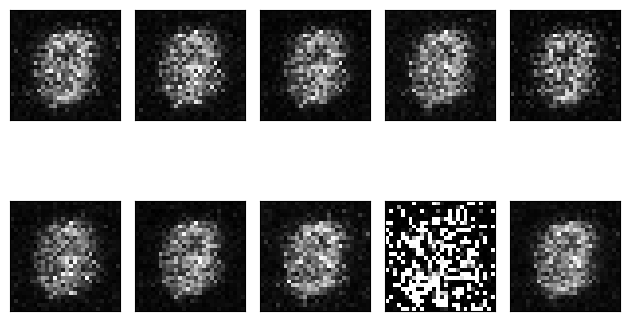

Epoch: 4, disc. loss: 0.33649811148643494, gen. loss: 1.8559733629226685. Time for epoch 5 is 26.111955881118774 sec
Epoch: 5, disc. loss: 0.43767356872558594, gen. loss: 1.237406849861145. Time for epoch 6 is 25.75658369064331 sec
Epoch: 6, disc. loss: 0.4729020595550537, gen. loss: 0.9546877145767212. Time for epoch 7 is 25.737462997436523 sec
Epoch: 7, disc. loss: 0.497430682182312, gen. loss: 0.9698173999786377. Time for epoch 8 is 25.85486388206482 sec
Epoch: 8, disc. loss: 0.5337239503860474, gen. loss: 0.7856295108795166. Time for epoch 9 is 25.647775888442993 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


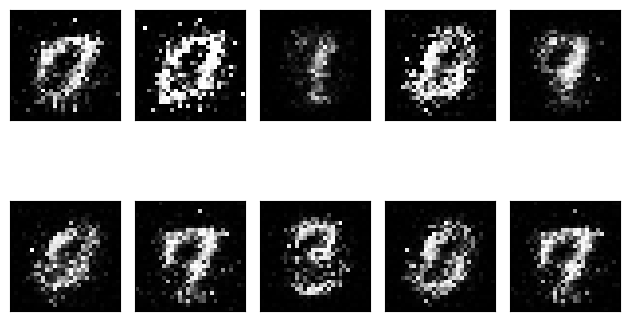

Epoch: 9, disc. loss: 0.5485861897468567, gen. loss: 0.7764988541603088. Time for epoch 10 is 26.123788833618164 sec
Epoch: 10, disc. loss: 0.5458650588989258, gen. loss: 0.8681440353393555. Time for epoch 11 is 25.831629037857056 sec
Epoch: 11, disc. loss: 0.5849151611328125, gen. loss: 0.731558084487915. Time for epoch 12 is 25.767040967941284 sec
Epoch: 12, disc. loss: 0.5497678518295288, gen. loss: 1.0020452737808228. Time for epoch 13 is 25.937987804412842 sec
Epoch: 13, disc. loss: 0.7143175601959229, gen. loss: 1.500654697418213. Time for epoch 14 is 25.7721951007843 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


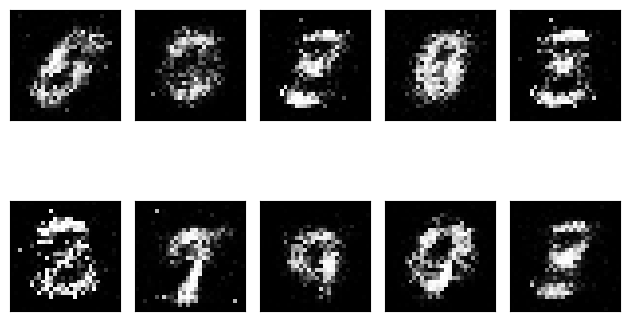

Epoch: 14, disc. loss: 0.6730927228927612, gen. loss: 0.4426645040512085. Time for epoch 15 is 25.997365713119507 sec
Epoch: 15, disc. loss: 0.5976447463035583, gen. loss: 0.5732309222221375. Time for epoch 16 is 25.84993076324463 sec
Epoch: 16, disc. loss: 0.646945595741272, gen. loss: 0.4928714632987976. Time for epoch 17 is 25.786383152008057 sec
Epoch: 17, disc. loss: 0.6174187064170837, gen. loss: 0.6776742339134216. Time for epoch 18 is 25.809415340423584 sec
Epoch: 18, disc. loss: 0.6096991896629333, gen. loss: 0.5980948209762573. Time for epoch 19 is 25.675008058547974 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


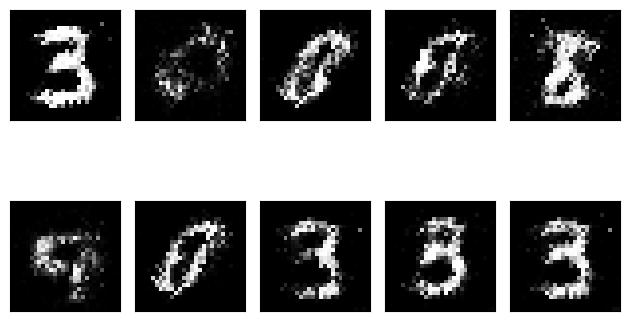

Epoch: 19, disc. loss: 0.6305165886878967, gen. loss: 1.231683373451233. Time for epoch 20 is 26.16347360610962 sec
Epoch: 20, disc. loss: 0.5977905988693237, gen. loss: 0.7667754888534546. Time for epoch 21 is 25.69823980331421 sec
Epoch: 21, disc. loss: 0.6430400013923645, gen. loss: 0.9630210399627686. Time for epoch 22 is 25.855174779891968 sec
Epoch: 22, disc. loss: 0.592943549156189, gen. loss: 0.8418257236480713. Time for epoch 23 is 25.732739210128784 sec
Epoch: 23, disc. loss: 0.6441697478294373, gen. loss: 1.0631728172302246. Time for epoch 24 is 25.802895069122314 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


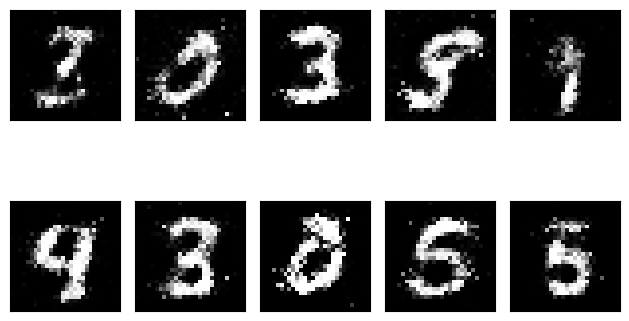

Epoch: 24, disc. loss: 0.6960659027099609, gen. loss: 0.5341196656227112. Time for epoch 25 is 26.603190660476685 sec
Epoch: 25, disc. loss: 0.6151518225669861, gen. loss: 0.7690721750259399. Time for epoch 26 is 25.84408450126648 sec
Epoch: 26, disc. loss: 0.5870005488395691, gen. loss: 1.021950125694275. Time for epoch 27 is 26.073395490646362 sec
Epoch: 27, disc. loss: 0.5860880613327026, gen. loss: 0.7305625677108765. Time for epoch 28 is 25.82776403427124 sec
Epoch: 28, disc. loss: 0.6363644599914551, gen. loss: 0.6291360855102539. Time for epoch 29 is 25.725250244140625 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


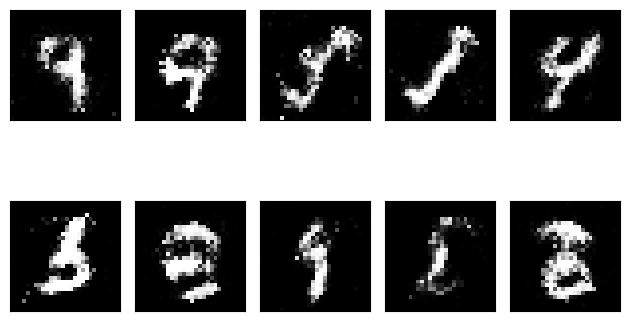

Epoch: 29, disc. loss: 0.6205785870552063, gen. loss: 0.986796498298645. Time for epoch 30 is 26.365004539489746 sec
Epoch: 30, disc. loss: 0.6982088088989258, gen. loss: 1.2881921529769897. Time for epoch 31 is 25.840256929397583 sec
Epoch: 31, disc. loss: 0.6241130828857422, gen. loss: 0.9106653928756714. Time for epoch 32 is 25.705941200256348 sec
Epoch: 32, disc. loss: 0.5971028804779053, gen. loss: 0.864065945148468. Time for epoch 33 is 25.80997109413147 sec
Epoch: 33, disc. loss: 0.6045815944671631, gen. loss: 0.8029209971427917. Time for epoch 34 is 25.77039933204651 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


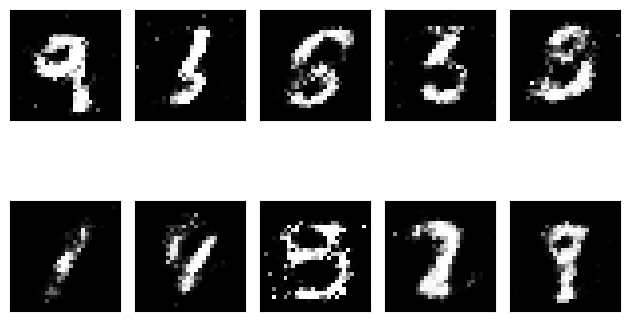

Epoch: 34, disc. loss: 0.644996166229248, gen. loss: 0.5418684482574463. Time for epoch 35 is 26.189149141311646 sec
Epoch: 35, disc. loss: 0.5940592288970947, gen. loss: 0.8329232931137085. Time for epoch 36 is 25.94019365310669 sec
Epoch: 36, disc. loss: 0.6041750311851501, gen. loss: 0.8211225271224976. Time for epoch 37 is 26.07069158554077 sec
Epoch: 37, disc. loss: 0.5887906551361084, gen. loss: 0.9051119089126587. Time for epoch 38 is 25.748440504074097 sec
Epoch: 38, disc. loss: 0.6244330406188965, gen. loss: 0.861041784286499. Time for epoch 39 is 25.822967052459717 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


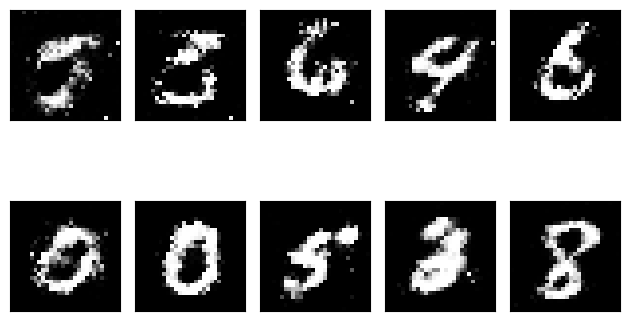

Epoch: 39, disc. loss: 0.6045958995819092, gen. loss: 1.0397272109985352. Time for epoch 40 is 26.18143057823181 sec
Epoch: 40, disc. loss: 0.6196544170379639, gen. loss: 0.8452641367912292. Time for epoch 41 is 25.83178734779358 sec
Epoch: 41, disc. loss: 0.6019812226295471, gen. loss: 1.0263590812683105. Time for epoch 42 is 25.797163486480713 sec
Epoch: 42, disc. loss: 0.6116852760314941, gen. loss: 0.8326418995857239. Time for epoch 43 is 25.722910165786743 sec
Epoch: 43, disc. loss: 0.6273803114891052, gen. loss: 1.0595937967300415. Time for epoch 44 is 25.741788387298584 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


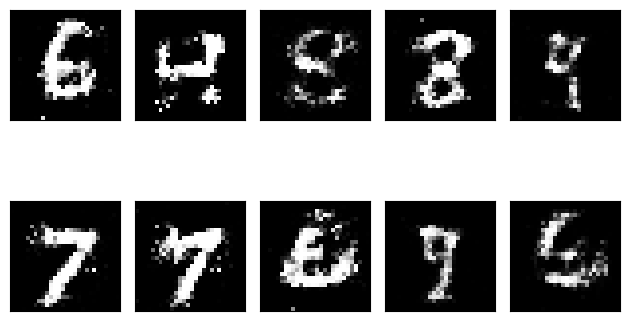

Epoch: 44, disc. loss: 0.6027854681015015, gen. loss: 0.7895414233207703. Time for epoch 45 is 26.26424264907837 sec
Epoch: 45, disc. loss: 0.6873102188110352, gen. loss: 1.3548492193222046. Time for epoch 46 is 25.869003534317017 sec
Epoch: 46, disc. loss: 0.6045461893081665, gen. loss: 0.7687875032424927. Time for epoch 47 is 25.83113670349121 sec
Epoch: 47, disc. loss: 0.6309000253677368, gen. loss: 0.6848742365837097. Time for epoch 48 is 25.883551120758057 sec
Epoch: 48, disc. loss: 0.6432133913040161, gen. loss: 0.8341016173362732. Time for epoch 49 is 25.86475396156311 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


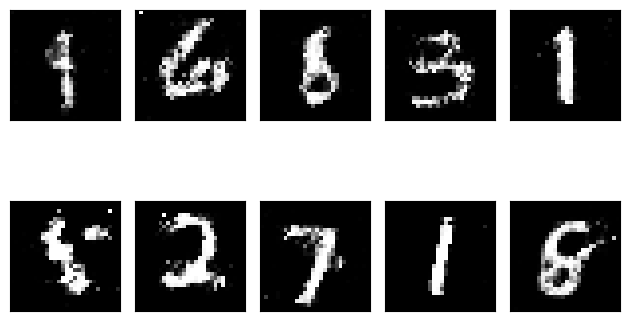

Epoch: 49, disc. loss: 0.614516019821167, gen. loss: 0.9561403393745422. Time for epoch 50 is 26.20539903640747 sec
Epoch: 50, disc. loss: 0.6747499704360962, gen. loss: 0.5924166440963745. Time for epoch 51 is 25.777629375457764 sec
Epoch: 51, disc. loss: 0.609213650226593, gen. loss: 0.7388899922370911. Time for epoch 52 is 25.947194576263428 sec
Epoch: 52, disc. loss: 0.6281894445419312, gen. loss: 0.7373908162117004. Time for epoch 53 is 25.807804107666016 sec
Epoch: 53, disc. loss: 0.6117749214172363, gen. loss: 0.7549848556518555. Time for epoch 54 is 25.69175148010254 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


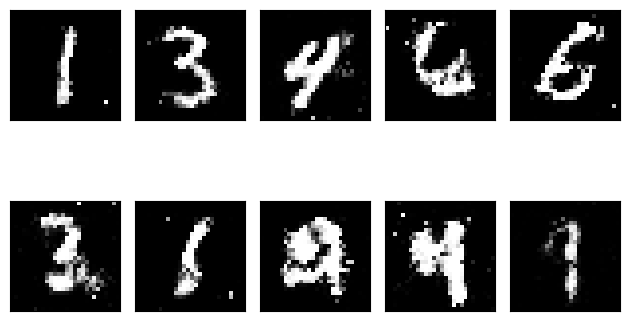

Epoch: 54, disc. loss: 0.619698166847229, gen. loss: 0.8673600554466248. Time for epoch 55 is 26.149441719055176 sec
Epoch: 55, disc. loss: 0.6056506633758545, gen. loss: 0.8343433737754822. Time for epoch 56 is 25.858068227767944 sec
Epoch: 56, disc. loss: 0.6228330731391907, gen. loss: 0.8461029529571533. Time for epoch 57 is 25.871930837631226 sec
Epoch: 57, disc. loss: 0.6131097078323364, gen. loss: 0.6827520728111267. Time for epoch 58 is 25.713948249816895 sec
Epoch: 58, disc. loss: 0.63641357421875, gen. loss: 0.811028242111206. Time for epoch 59 is 25.765840530395508 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


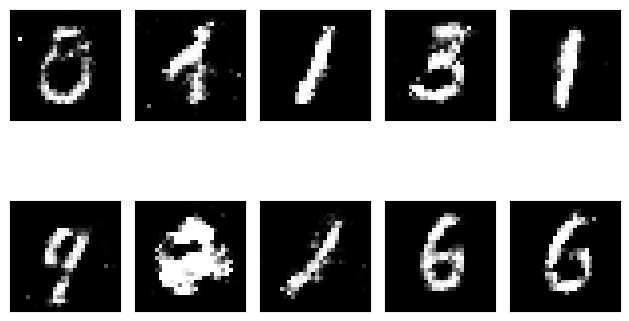

Epoch: 59, disc. loss: 0.6276509761810303, gen. loss: 0.8279747366905212. Time for epoch 60 is 26.1522696018219 sec
Epoch: 60, disc. loss: 0.5890445113182068, gen. loss: 0.9137324690818787. Time for epoch 61 is 25.927870512008667 sec
Epoch: 61, disc. loss: 0.6688261032104492, gen. loss: 0.6593061685562134. Time for epoch 62 is 25.842390060424805 sec
Epoch: 62, disc. loss: 0.621758222579956, gen. loss: 1.0416769981384277. Time for epoch 63 is 25.775537967681885 sec
Epoch: 63, disc. loss: 0.60107421875, gen. loss: 0.9706048965454102. Time for epoch 64 is 25.931411266326904 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


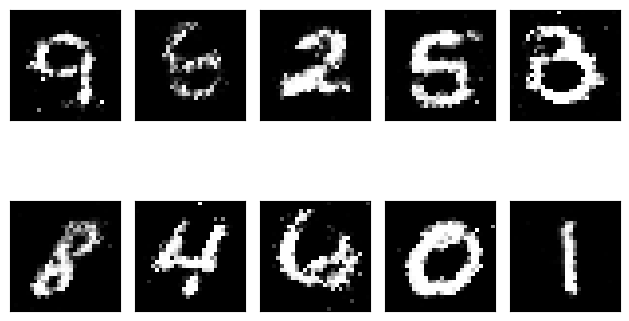

Epoch: 64, disc. loss: 0.6165650486946106, gen. loss: 0.875662624835968. Time for epoch 65 is 26.096032857894897 sec
Epoch: 65, disc. loss: 0.6356003284454346, gen. loss: 0.7804908752441406. Time for epoch 66 is 25.71124243736267 sec
Epoch: 66, disc. loss: 0.5886046886444092, gen. loss: 1.042117714881897. Time for epoch 67 is 25.85377812385559 sec
Epoch: 67, disc. loss: 0.6009082794189453, gen. loss: 0.7760226130485535. Time for epoch 68 is 25.865856409072876 sec
Epoch: 68, disc. loss: 0.6251209378242493, gen. loss: 1.1267269849777222. Time for epoch 69 is 25.7763352394104 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


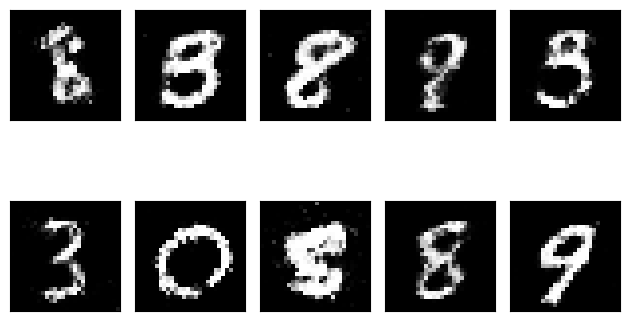

Epoch: 69, disc. loss: 0.6548781394958496, gen. loss: 0.9481525421142578. Time for epoch 70 is 26.167550086975098 sec
Epoch: 70, disc. loss: 0.6203632354736328, gen. loss: 0.7988933324813843. Time for epoch 71 is 25.87682056427002 sec
Epoch: 71, disc. loss: 0.6124883890151978, gen. loss: 0.7402680516242981. Time for epoch 72 is 25.801234245300293 sec
Epoch: 72, disc. loss: 0.5780528783798218, gen. loss: 0.7771061658859253. Time for epoch 73 is 25.940320253372192 sec
Epoch: 73, disc. loss: 0.617786169052124, gen. loss: 0.7815980911254883. Time for epoch 74 is 25.89867067337036 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


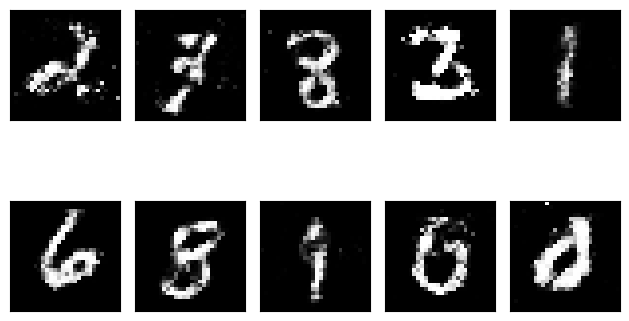

Epoch: 74, disc. loss: 0.5621994733810425, gen. loss: 1.041415810585022. Time for epoch 75 is 26.39135241508484 sec
Epoch: 75, disc. loss: 0.6344295144081116, gen. loss: 0.9248115420341492. Time for epoch 76 is 25.854970693588257 sec
Epoch: 76, disc. loss: 0.5846130847930908, gen. loss: 0.8148629665374756. Time for epoch 77 is 25.947877883911133 sec
Epoch: 77, disc. loss: 0.5814875960350037, gen. loss: 1.0812604427337646. Time for epoch 78 is 25.82448983192444 sec
Epoch: 78, disc. loss: 0.605793833732605, gen. loss: 1.0517221689224243. Time for epoch 79 is 25.88968014717102 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


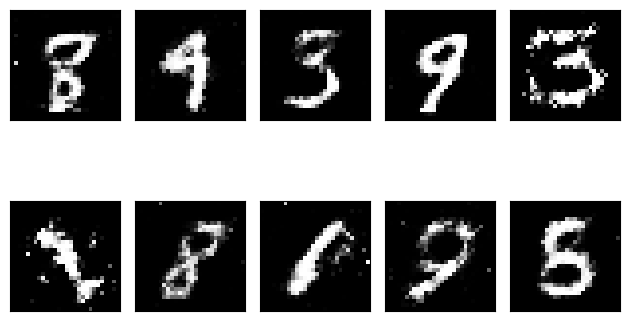

Epoch: 79, disc. loss: 0.6151843070983887, gen. loss: 0.8430507183074951. Time for epoch 80 is 26.339367389678955 sec
Epoch: 80, disc. loss: 0.6313790082931519, gen. loss: 0.6493662595748901. Time for epoch 81 is 25.844569206237793 sec
Epoch: 81, disc. loss: 0.6386501789093018, gen. loss: 0.8890058994293213. Time for epoch 82 is 25.841863870620728 sec
Epoch: 82, disc. loss: 0.619641125202179, gen. loss: 0.7636936902999878. Time for epoch 83 is 25.980576276779175 sec
Epoch: 83, disc. loss: 0.6292802095413208, gen. loss: 0.6477122902870178. Time for epoch 84 is 25.83017611503601 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


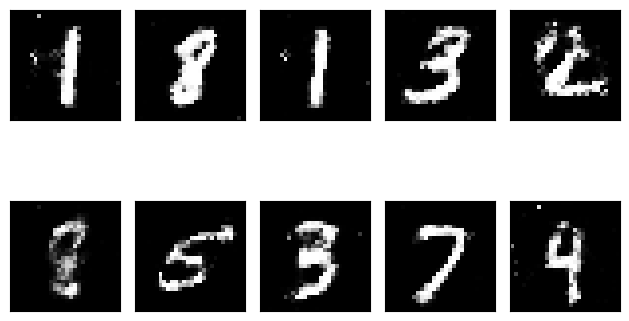

Epoch: 84, disc. loss: 0.6224752068519592, gen. loss: 0.8233528137207031. Time for epoch 85 is 26.32817506790161 sec
Epoch: 85, disc. loss: 0.6131218671798706, gen. loss: 0.6016241312026978. Time for epoch 86 is 26.058552503585815 sec
Epoch: 86, disc. loss: 0.6236581802368164, gen. loss: 0.8988469839096069. Time for epoch 87 is 25.886309385299683 sec
Epoch: 87, disc. loss: 0.6003177165985107, gen. loss: 0.6719026565551758. Time for epoch 88 is 25.759159326553345 sec
Epoch: 88, disc. loss: 0.6205435395240784, gen. loss: 0.8714063763618469. Time for epoch 89 is 25.73754358291626 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


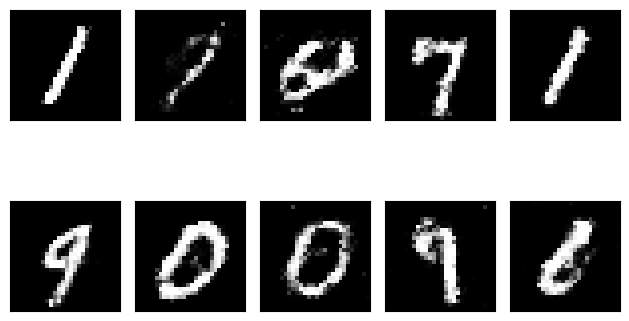

Epoch: 89, disc. loss: 0.6560734510421753, gen. loss: 0.7204736471176147. Time for epoch 90 is 26.13808250427246 sec
Epoch: 90, disc. loss: 0.6134413480758667, gen. loss: 1.0670747756958008. Time for epoch 91 is 25.84981060028076 sec
Epoch: 91, disc. loss: 0.5811868906021118, gen. loss: 0.8625264167785645. Time for epoch 92 is 25.763171434402466 sec
Epoch: 92, disc. loss: 0.599625825881958, gen. loss: 0.73385089635849. Time for epoch 93 is 25.878303289413452 sec
Epoch: 93, disc. loss: 0.6136176586151123, gen. loss: 0.8631646037101746. Time for epoch 94 is 25.80911350250244 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


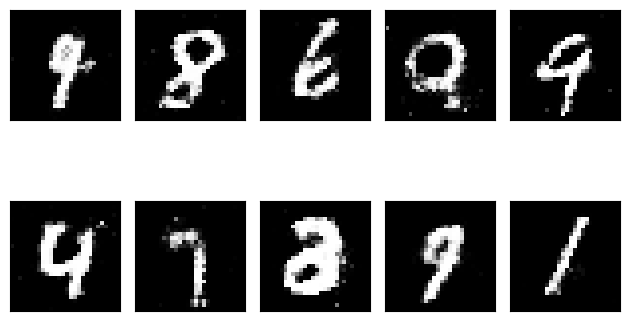

Epoch: 94, disc. loss: 0.5951834321022034, gen. loss: 1.112607717514038. Time for epoch 95 is 26.028474807739258 sec
Epoch: 95, disc. loss: 0.6324360370635986, gen. loss: 0.6753368973731995. Time for epoch 96 is 25.696229219436646 sec
Epoch: 96, disc. loss: 0.5789393186569214, gen. loss: 0.8559271097183228. Time for epoch 97 is 25.787185430526733 sec
Epoch: 97, disc. loss: 0.6181896328926086, gen. loss: 1.2053383588790894. Time for epoch 98 is 25.706960916519165 sec
Epoch: 98, disc. loss: 0.5916821956634521, gen. loss: 0.8302571177482605. Time for epoch 99 is 25.79871964454651 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


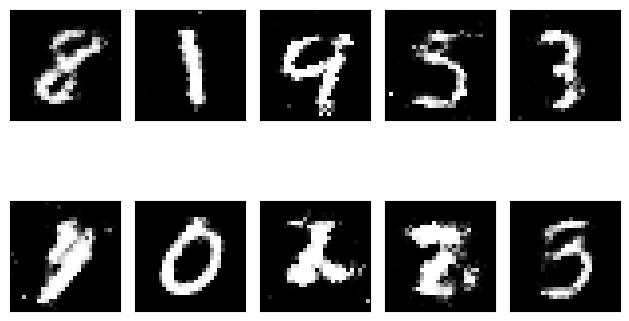

Epoch: 99, disc. loss: 0.6248422861099243, gen. loss: 0.8433755040168762. Time for epoch 100 is 26.12220811843872 sec


In [10]:
import time

# smooth = 0.1
add_noise_labels = True
noise_labels = 0.02

gen_optimizer = Adam( learning_rate=0.0002, beta_1=0.5 )
disc_optimizer = Adam( learning_rate=0.0002, beta_1=0.5 )
# cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)
cross_entropy = tf.keras.losses.BinaryCrossentropy()

@tf.function
def train_step( X_real ):
    z = tf.random.normal( [batch_size, latent_dim] )

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      X_fake = generator( z, training=True )

      real_output = discriminator( X_real, training=True)
      fake_output = discriminator( X_fake, training=True)

      y_real = tf.ones_like(real_output)
      y_fake = tf.zeros_like(fake_output)
      # Add random noise to the labels
      if add_noise_labels:
          y_real += noise_labels * tf.random.uniform(tf.shape(y_real))
          y_fake += noise_labels * tf.random.uniform(tf.shape(y_fake))
        
      real_loss = cross_entropy( y_real, real_output)
      fake_loss = cross_entropy( y_fake, fake_output)
      disc_loss = 0.5 * ( real_loss + fake_loss )
        
      gen_loss = cross_entropy( tf.ones_like(fake_output), fake_output )

    gen_grads  = gen_tape.gradient( gen_loss, generator.trainable_variables )
    disc_grads = disc_tape.gradient( disc_loss, discriminator.trainable_variables )

    gen_optimizer.apply_gradients( zip( gen_grads, generator.trainable_variables) )
    disc_optimizer.apply_gradients( zip( disc_grads, discriminator.trainable_variables) )

    return (disc_loss, gen_loss)

def train(dataset, epochs):
  for epoch in range(epochs):
    start = time.time()

    for X_batch in dataset:
      dloss, gloss = train_step( X_batch )

    if (epoch + 1) % 5 == 0:
        samples = 10
        X_ = generator.predict( tf.random.normal( [samples, latent_dim] ) )
        for k in range(samples):
            plt.subplot(2, 5, k+1)
            plt.imshow( X_[k].reshape(28, 28), cmap='gray')
            plt.xticks([])
            plt.yticks([])
        plt.tight_layout()
        plt.show()

    print ( "Epoch: {}, disc. loss: {}, gen. loss: {}.".format( epoch, dloss, gloss ),
            "Time for epoch {} is {} sec".format(epoch + 1, time.time()-start) )
   
epochs = 100
train(train_dataset, epochs)    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


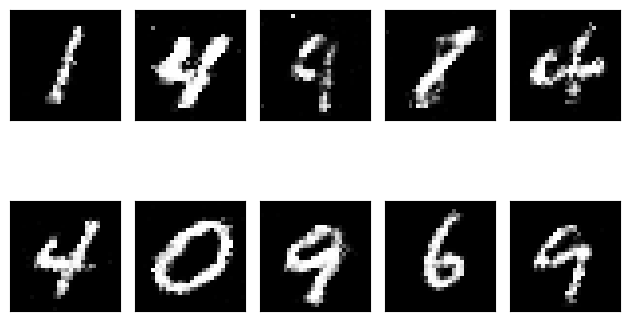

In [19]:
samples = 10
X_ = generator.predict( tf.random.normal( [samples, latent_dim] ) )
for k in range(samples):
    plt.subplot(2, 5, k+1)
    plt.imshow( X_[k].reshape(28, 28), cmap='gray')
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()